# SEED per-trial preprocessing

**Purpose:** Preprocess raw SEED `.mat` files into per-trial DE features aligned with DEAP preprocessing, for use in Report 7 (cross-dataset DEAP → SEED test).

**Run this locally on your Windows machine** — CPU-only, no GPU needed.

**Pipeline per film (trial):**
1. Select 32 DEAP-matching channels from SEED's 62
2. Resample 200 Hz → 128 Hz (match DEAP sampling rate)
3. Band-pass filter 4-45 Hz (match DEAP filtering)
4. Compute Differential Entropy per frequency band on the full film signal
5. Result: 32 channels × 5 bands = 160-d feature vector per trial

**Output:**
- `X_seed_DE_pertrial.npy` — (675, 160) DE features
- `y_seed_pertrial.npy` — (675,) labels {0=Neg, 1=Neu, 2=Pos}
- `subj_seed_pertrial.npy` — (675,) subject IDs 1..15

**Runtime:** ~10-30 min on typical CPU.

**Then upload the 3 `.npy` files to Google Drive:** `/content/drive/MyDrive/case_study_2/processed/`

## 1. Setup — install dependencies (only needed once)

In [1]:
# Uncomment ONE line based on your Python environment, then run once.

# If you have Anaconda:
# !conda install -y numpy scipy

# If plain Python or unsure:
# !pip install numpy scipy

# Skip this cell if numpy + scipy are already installed.

## 2. Imports

In [2]:
import os
import sys
import re
from pathlib import Path
import numpy as np
from scipy import signal as scisig
from scipy.io import loadmat

print(f'numpy: {np.__version__}')
import scipy
print(f'scipy: {scipy.__version__}')

numpy: 2.4.6
scipy: 1.17.1


## 3. Configuration — EDIT PATHS BELOW

Set `SEED_ROOT` to point to your `Preprocessed_EEG` folder.
Set `OUTPUT_DIR` to where you want the 3 `.npy` files written.

In [3]:
# EDIT THESE TO MATCH YOUR SETUP:

SEED_ROOT   = r"V:\Data_Analytics\case study 2\seed dataset\SEED_EEG\Preprocessed_EEG"
OUTPUT_DIR  = r"V:\Data_Analytics\case study 2\seed dataset\SEED_EEG\pertrial_output"

# ----------------------------------------------------------
# Constants matched to your DEAP preprocessing
# ----------------------------------------------------------
FS_SEED_ORIG = 200   # SEED original sampling rate
FS_TARGET    = 128   # DEAP sampling rate

# Frequency bands (Hz) — same as your R1 preprocessing
BANDS = {
    'theta':     (4, 8),
    'alpha':     (8, 14),
    'beta_low':  (14, 20),
    'beta_high': (20, 30),
    'gamma':     (30, 45),
}

# SEED's 62 channels in file order (from channel-order.xlsx)
SEED_62_CHANNELS = [
    'FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ',
    'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2',
    'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4',
    'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6',
    'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8',
    'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'OZ',
    'O2', 'CB2',
]

# DEAP's 32 channels
DEAP_32_CHANNELS = [
    'FP1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7',
    'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'OZ', 'PZ',
    'FP2', 'AF4', 'FZ', 'F4', 'F8', 'FC6', 'FC2', 'CZ',
    'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2',
]

# Indices of DEAP channels within SEED's 62-channel order
DEAP_CHANNEL_INDICES = [SEED_62_CHANNELS.index(ch) for ch in DEAP_32_CHANNELS]
print(f'DEAP-matching channels found in SEED: {len(DEAP_CHANNEL_INDICES)}/32')

# Label sequence per session (from readme.txt) — same for ALL 3 sessions
# 1 = Positive, 0 = Neutral, -1 = Negative
LABELS_PER_SESSION_RAW = np.array(
    [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1], dtype=np.int64
)
# Remap to {0=Neg, 1=Neu, 2=Pos} to match your R1 label convention
LABEL_MAP = {-1: 0, 0: 1, 1: 2}
LABELS_PER_SESSION = np.array([LABEL_MAP[v] for v in LABELS_PER_SESSION_RAW], dtype=np.int64)
print(f'Labels per session (remapped): {LABELS_PER_SESSION.tolist()}')

DEAP-matching channels found in SEED: 32/32
Labels per session (remapped): [2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 1, 0, 1, 2, 0]


## 4. Verify SEED folder is accessible

In [4]:
seed_root = Path(SEED_ROOT)
output_dir = Path(OUTPUT_DIR)

if not seed_root.exists():
    print(f'ERROR: SEED root not found: {seed_root}')
    print('Fix the SEED_ROOT path in cell 3 above.')
else:
    print(f'SEED root: {seed_root}   OK')

mat_files = sorted([f for f in seed_root.glob('*.mat') if f.name != 'label.mat'])
print(f'Session .mat files found: {len(mat_files)}   (expected 45)')

if len(mat_files) > 0:
    print(f'Example filenames:')
    for f in mat_files[:3]:
        print(f'  {f.name}')

output_dir.mkdir(parents=True, exist_ok=True)
print(f'\nOutput dir: {output_dir}   OK')

SEED root: V:\Data_Analytics\case study 2\seed dataset\SEED_EEG\Preprocessed_EEG   OK
Session .mat files found: 45   (expected 45)
Example filenames:
  10_20131130.mat
  10_20131204.mat
  10_20131211.mat

Output dir: V:\Data_Analytics\case study 2\seed dataset\SEED_EEG\pertrial_output   OK


## 5. Helper functions

In [5]:
def bandpass_filter(x, low, high, fs, order=5):
    """Zero-phase Butterworth band-pass filter along last axis."""
    nyq = fs / 2.0
    b, a = scisig.butter(order, [low / nyq, high / nyq], btype='band')
    return scisig.filtfilt(b, a, x, axis=-1)

def compute_de(signal_1d):
    """Differential Entropy of a Gaussian-approximated signal."""
    var = np.var(signal_1d)
    if var <= 0:
        return 0.0
    return 0.5 * np.log(2 * np.pi * np.e * var)

def resample_signal(x, fs_orig, fs_target):
    """Resample along last axis using polyphase filtering."""
    if fs_orig == fs_target:
        return x
    return scisig.resample_poly(x, up=fs_target, down=fs_orig, axis=-1)

def parse_subject_id_from_filename(filename):
    """Extract subject ID (1..15) from filenames like '6_20131113.mat'."""
    m = re.match(r'^(\d+)_\d+\.mat$', filename)
    return int(m.group(1)) if m else None

def extract_trial_variables(mat_dict):
    """Find EEG trial variables inside a session .mat file."""
    trials = []
    for key in mat_dict.keys():
        if key.startswith('__'):
            continue
        m = re.match(r'^.*_eeg(\d+)$', key)
        if m:
            trial_num = int(m.group(1))
            trials.append((trial_num, mat_dict[key]))
    trials.sort(key=lambda t: t[0])
    return trials

## 6. Test on ONE file before running the whole batch
Sanity check — make sure the file structure is what we expect.

In [6]:
if len(mat_files) > 0:
    test_file = mat_files[0]
    print(f'Testing on: {test_file.name}')
    mat = loadmat(str(test_file))
    trials = extract_trial_variables(mat)
    print(f'Trials found: {len(trials)}   (expected 15)')
    if trials:
        first_trial_num, first_eeg = trials[0]
        print(f'First trial: number={first_trial_num}, shape={first_eeg.shape}')
        print(f'  channels={first_eeg.shape[0]} (expected 62), time samples={first_eeg.shape[1]}')
        print(f'  duration at 200Hz: {first_eeg.shape[1]/200:.1f} seconds')
else:
    print('No files to test — check SEED_ROOT path above.')

Testing on: 10_20131130.mat
Trials found: 15   (expected 15)
First trial: number=1, shape=(62, 47001)
  channels=62 (expected 62), time samples=47001
  duration at 200Hz: 235.0 seconds


## 7. Process one film — end-to-end pipeline

In [7]:
def process_one_film(eeg_film, fs_orig, channel_indices):
    """Process a single film's EEG.

    Args:
        eeg_film: (62, T) numpy array at fs_orig Hz
        fs_orig: original sampling rate (200 Hz for SEED)
        channel_indices: list of 32 indices into the 62 channels

    Returns:
        DE vector of shape (160,) — 32 channels x 5 bands, flattened
    """
    eeg = eeg_film[channel_indices, :]                       # (32, T)
    eeg = resample_signal(eeg, fs_orig, FS_TARGET)           # (32, T')
    n_channels = eeg.shape[0]
    n_bands = len(BANDS)
    de_matrix = np.zeros((n_channels, n_bands), dtype=np.float32)
    for b_idx, (band_name, (low, high)) in enumerate(BANDS.items()):
        filtered = bandpass_filter(eeg, low, high, FS_TARGET, order=5)
        for c_idx in range(n_channels):
            de_matrix[c_idx, b_idx] = compute_de(filtered[c_idx, :])
    return de_matrix.reshape(-1).astype(np.float32)          # (160,)

# Test on one film
if len(mat_files) > 0 and trials:
    de_test = process_one_film(first_eeg, FS_SEED_ORIG, DEAP_CHANNEL_INDICES)
    print(f'Test DE vector: shape={de_test.shape}, dtype={de_test.dtype}')
    print(f'  values range: [{de_test.min():.4f}, {de_test.max():.4f}]')
    print(f'  mean={de_test.mean():.4f}, std={de_test.std():.4f}')

Test DE vector: shape=(160,), dtype=float32
  values range: [-0.4934, 4.0086]
  mean=2.2303, std=0.6677


## 8. Process all subjects (main loop)
This is the slow step — ~10-30 minutes.

In [8]:
import time

# Group session files by subject
subject_sessions = {}
for f in mat_files:
    sid = parse_subject_id_from_filename(f.name)
    if sid is None:
        print(f'WARNING: cannot parse subject id from {f.name}, skipping')
        continue
    subject_sessions.setdefault(sid, []).append(f)

print(f'Subjects found: {sorted(subject_sessions.keys())}')

# Sort sessions chronologically per subject
for sid in subject_sessions:
    subject_sessions[sid].sort(key=lambda f: f.name)

all_X, all_y, all_s = [], [], []
t_start = time.time()

for sid in sorted(subject_sessions.keys()):
    sessions = subject_sessions[sid]
    t_sub = time.time()
    print(f'\n===== Subject {sid} — {len(sessions)} sessions =====')
    subject_X, subject_y = [], []

    for sess_idx, sess_file in enumerate(sessions, start=1):
        mat = loadmat(str(sess_file))
        trials = extract_trial_variables(mat)
        print(f'  session {sess_idx} ({sess_file.name}): {len(trials)} trials')
        if len(trials) != 15:
            print(f'    WARNING: expected 15 trials, got {len(trials)}')

        for trial_num, eeg_film in trials:
            if eeg_film.shape[0] != 62:
                print(f'    WARNING: expected 62 channels, got {eeg_film.shape[0]}')
                continue
            de_vec = process_one_film(eeg_film, FS_SEED_ORIG, DEAP_CHANNEL_INDICES)
            label = LABELS_PER_SESSION[trial_num - 1]
            subject_X.append(de_vec)
            subject_y.append(label)

    subject_X = np.stack(subject_X, axis=0)
    subject_y = np.array(subject_y, dtype=np.int64)
    subject_s = np.full(len(subject_y), sid, dtype=np.int64)

    # Per-subject z-score across trials
    mu  = subject_X.mean(axis=0, keepdims=True)
    std = subject_X.std(axis=0, keepdims=True) + 1e-8
    subject_X = ((subject_X - mu) / std).astype(np.float32)

    print(f'  final: X {subject_X.shape}, y counts {np.bincount(subject_y).tolist()}, time={time.time()-t_sub:.1f}s')

    all_X.append(subject_X)
    all_y.append(subject_y)
    all_s.append(subject_s)

X_final = np.concatenate(all_X, axis=0)
y_final = np.concatenate(all_y, axis=0)
s_final = np.concatenate(all_s, axis=0)

print(f'\n===== FINAL =====')
print(f'X: {X_final.shape}   dtype={X_final.dtype}')
print(f'y: {y_final.shape}   counts={np.bincount(y_final).tolist()}')
print(f'subjects: {s_final.shape}   unique={np.unique(s_final).tolist()}')
print(f'Total time: {time.time()-t_start:.1f}s')

Subjects found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

===== Subject 1 — 3 sessions =====
  session 1 (1_20131027.mat): 15 trials
  session 2 (1_20131030.mat): 15 trials
  session 3 (1_20131107.mat): 15 trials
  final: X (45, 160), y counts [15, 15, 15], time=24.2s

===== Subject 2 — 3 sessions =====
  session 1 (2_20140404.mat): 15 trials
  session 2 (2_20140413.mat): 15 trials
  session 3 (2_20140419.mat): 15 trials
  final: X (45, 160), y counts [15, 15, 15], time=21.8s

===== Subject 3 — 3 sessions =====
  session 1 (3_20140603.mat): 15 trials
  session 2 (3_20140611.mat): 15 trials
  session 3 (3_20140629.mat): 15 trials
  final: X (45, 160), y counts [15, 15, 15], time=19.4s

===== Subject 4 — 3 sessions =====
  session 1 (4_20140621.mat): 15 trials
  session 2 (4_20140702.mat): 15 trials
  session 3 (4_20140705.mat): 15 trials
  final: X (45, 160), y counts [15, 15, 15], time=19.2s

===== Subject 5 — 3 sessions =====
  session 1 (5_20140411.mat): 15 trials
  sessio

## 9. Save outputs

In [9]:
x_path = output_dir / 'X_seed_DE_pertrial.npy'
y_path = output_dir / 'y_seed_pertrial.npy'
s_path = output_dir / 'subj_seed_pertrial.npy'

np.save(x_path, X_final)
np.save(y_path, y_final)
np.save(s_path, s_final)

print(f'Saved to: {output_dir}\n')
for p in [x_path, y_path, s_path]:
    print(f'  {p.name}   ({p.stat().st_size / 1024:.1f} KB)')

print('\n=== NEXT STEP ===')
print('Upload these 3 files to Google Drive:')
print('  /content/drive/MyDrive/case_study_2/processed/')

Saved to: V:\Data_Analytics\case study 2\seed dataset\SEED_EEG\pertrial_output

  X_seed_DE_pertrial.npy   (422.0 KB)
  y_seed_pertrial.npy   (5.4 KB)
  subj_seed_pertrial.npy   (5.4 KB)

=== NEXT STEP ===
Upload these 3 files to Google Drive:
  /content/drive/MyDrive/case_study_2/processed/


## 10. Quick sanity plots (optional)

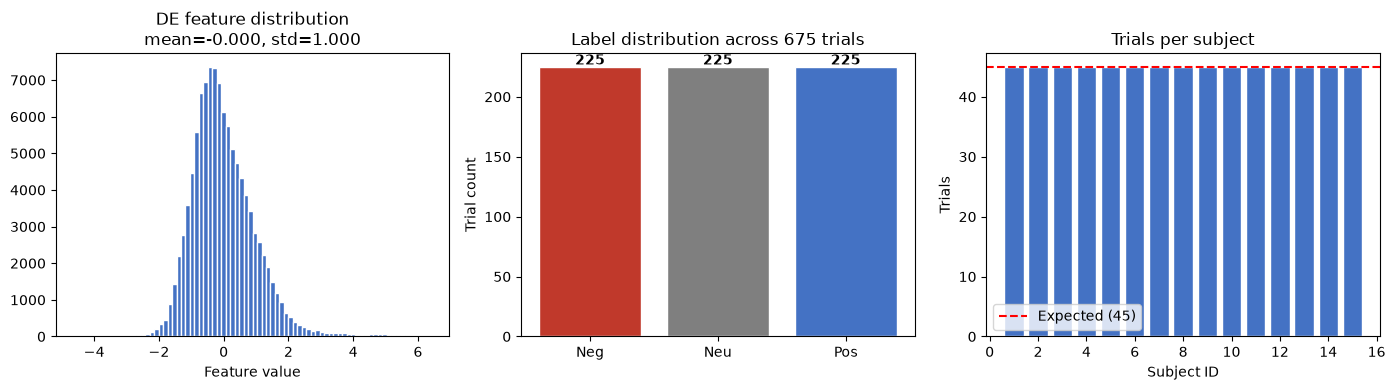

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Feature distribution (should be roughly zero-mean after z-score)
axes[0].hist(X_final.flatten(), bins=80, color='#4472C4', edgecolor='white')
axes[0].set_title(f'DE feature distribution\nmean={X_final.mean():.3f}, std={X_final.std():.3f}')
axes[0].set_xlabel('Feature value')

# 2. Label distribution
counts = np.bincount(y_final)
axes[1].bar(['Neg', 'Neu', 'Pos'], counts, color=['#c0392b', '#7f7f7f', '#4472C4'], edgecolor='white')
for i, c in enumerate(counts):
    axes[1].text(i, c + 2, str(c), ha='center', fontweight='bold')
axes[1].set_title('Label distribution across 675 trials')
axes[1].set_ylabel('Trial count')

# 3. Samples per subject (should be 45 each)
sub_counts = [np.sum(s_final == s) for s in range(1, 16)]
axes[2].bar(range(1, 16), sub_counts, color='#4472C4', edgecolor='white')
axes[2].axhline(45, color='red', linestyle='--', label='Expected (45)')
axes[2].set_title('Trials per subject')
axes[2].set_xlabel('Subject ID')
axes[2].set_ylabel('Trials')
axes[2].legend()

plt.tight_layout()
plt.savefig(output_dir / 'seed_pertrial_sanity.png', dpi=100)
plt.show()